Montamos el Directorio Google Drive donde guardaremos los datos experimentales

In [1]:
from google.colab import drive
drive.mount ('/content/drive')
import os
os.chdir('/content/drive/My Drive/Física Exp III datos')

Mounted at /content/drive


Listamos los archivos contenidos en el directorio de los datos experimentales

In [2]:
!ls

vc-carga.txt  vc-descarga.txt  vr-carga.txt  vr-descarga.txt


Intentamos un programa de ajuste de datos experimentales con comportamienot no lineal.

En este bloque se importan todas la librerias que se usarán durante la ejecución del programa

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax
from scipy.optimize import curve_fit,least_squares
from scipy import stats
from scipy.stats.distributions import  t
import math

El cuarto bloque es el ingreso de datos. Pueden ser cargados manulamente desde este mismo programa o se pueden cargar desde un archivo previamente grabado. Para leer los datos desde un archivo, los datos deben estar previamente guardados en el Google Drive de su cuenta personal Google que le brindó la UNC. Para montar el Google Drive en Colab, ir al menú vertical de la izquierda. Allí en la parte superior verá el símbolo de Google Drive. Activar haciendo click sobre el símbolo con el botón izquierdo del ratón. En el mismo menú vertical aparecerá un directorio denominado drive, navegue dentro de este directorio hasta ubicar el archivo con los datos experimentales. Haga click con el botón derecho del ratón sobre el símbolo del archivo de datos. Luego elija "copiar la ruta de acceso". La ruta ya queda copiada en memoria. Cuando el programa le solicite el nombre del archivo con los datos, solo tiene que hacer "crtl V" en el recuadro correspondiente, luego "enter". Si alguien descubre una forma más sencilla nos avisa.

NOTA: no guarde datos en el sitio de Google Colab, dado que estos se borran al momento de salir de la aplicación. Por otra parte la aplicación se cierra automáticamente luego de un cierto tiempo de inactividad.

In [4]:
import numpy as np

print('¿ingresa los datos desde archivo (S/N)?')
respuesta = input()

if (respuesta == "S" or respuesta == "s"):
        print('Ingrese el nombre del archivo con los datos (ej: resistencia_carga_4col.txt)')
        archivo_datos = str(input())

        # Cargamos los datos completos en una matriz.
        # Al usar delimiter='\t', NumPy lee automáticamente los decimales con punto.
        DATOS_todos = np.genfromtxt(archivo_datos, delimiter='\t')

        # Extraemos cada columna por separado en un vector (T, V, Err_T, Err_V)
        x_dato = DATOS_todos[:,0]
        y_dato = DATOS_todos[:,1]
        x_error = DATOS_todos[:,2]
        y_error = DATOS_todos[:,3]

        nd = len(x_dato)
        print('\n¡Archivo leído con éxito!')
        print('Cantidad de datos =', nd)

else:
        print('Ingrese el nombre del archivo donde va a grabar los datos')
        archivo_datos = str(input())

        nd = int(input('Ingrese la cantidad de datos: '))

        print('Ingrese los valores de la variable independiente (x_dato)=')
        x_dato = np.arange(nd, dtype=float)
        for i in range(nd):
            print('x[',i,']=', end= " ")
            x_dato[i] = float(input())

        print('Ingrese los errores de la variable independiente (x_error)=')
        x_error = np.arange(nd, dtype=float)
        for i in range(nd):
            print('x_err[',i,']=', end= " ")
            x_error[i] = float(input())

        print('Ingrese los valores de la variable dependiente (y_dato)=')
        y_dato = np.arange(nd, dtype=float)
        for i in range(nd):
            print('y[',i,']=', end= " ")
            y_dato[i] = float(input())

        print('Ingrese los errores de la variable dependiente (y_error)=')
        y_error = np.arange(nd, dtype=float)
        for i in range(nd):
            print('y_err[',i,']=', end= " ")
            y_error[i] = float(input())

        # Corrección: el delimitador de tabulación es '\t', no '\tab'
        np.savetxt(archivo_datos, np.array([x_dato, y_dato, x_error, y_error]).T, delimiter="\t", fmt='%.5f')

¿ingresa los datos desde archivo (S/N)?
s
Ingrese el nombre del archivo con los datos (ej: resistencia_carga_4col.txt)
vr-descarga.txt

¡Archivo leído con éxito!
Cantidad de datos = 2500


grafico comun


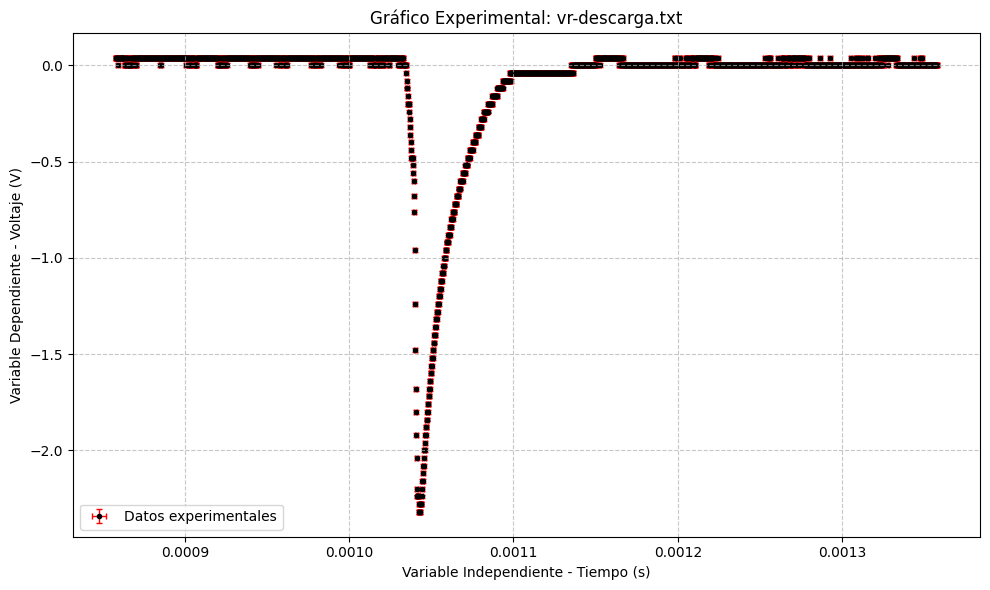

In [5]:
# Creamos la figura con un tamaño adecuado
plt.figure(figsize=(10, 6))

# Graficamos los datos con sus barras de error en X e Y
plt.errorbar(
    x_dato,              # Eje X
    y_dato,              # Eje Y
    xerr=x_error,        # Errores en X (barras horizontales)
    yerr=y_error,        # Errores en Y (barras verticales)
    fmt='.',             # Formato del punto (un punto pequeño)
    color='black',       # Color del marcador
    ecolor='red',        # Color de las barras de error
    elinewidth=1,        # Grosor de las líneas de error
    capsize=2,           # Tamaño de las "tapitas" en los extremos del error
    label='Datos experimentales',
    zorder=1
)

# Etiquetas, título y estilo
plt.title(f'Gráfico Experimental: {archivo_datos}')
plt.xlabel('Variable Independiente - Tiempo (s)')
plt.ylabel('Variable Dependiente - Voltaje (V)')

# Añadimos una grilla para leer mejor los valores
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')

# Ajustamos los márgenes para que todo se vea bien
plt.tight_layout()

# Mostramos el gráfico
plt.show()

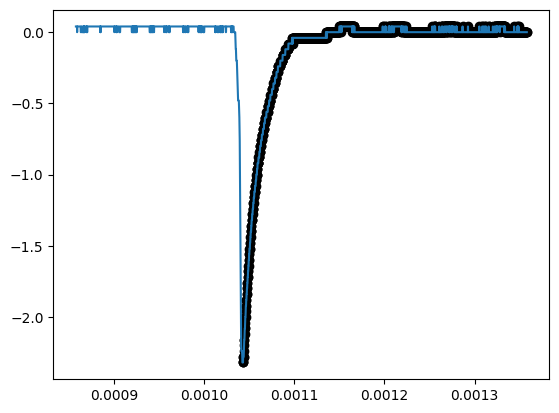

In [7]:
a=924
x_dato1 = x_dato[a:2500]
y_dato1 = y_dato[a:2500]
y_error1 = y_error[a:2500]
x_error1 = x_error[a:2500]
plt.plot(x_dato,y_dato)
plt.scatter(x_dato1,y_dato1, color='k')

Acá hacemos un gráfico de los datos experimentales con sus incertezas de medición

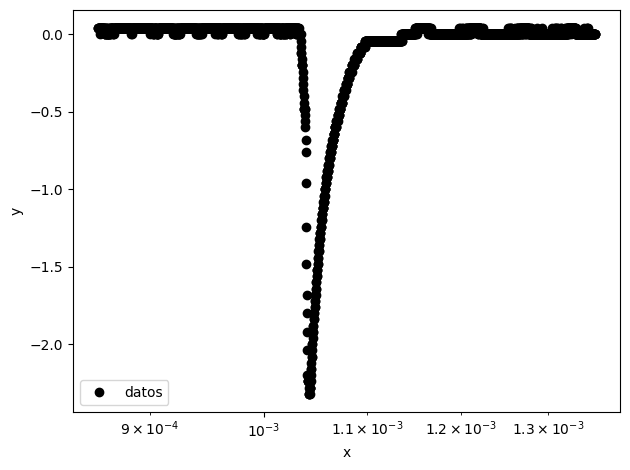

In [8]:
# plt.figure()
# plt.errorbar(x_dato, y_dato, yerr=y_error, xerr=x_error,
  #           fmt='.k', capsize=2, zorder=0)
fig, (ax1) = plt.subplots(1, 1)
ax1.set_xscale('log')
plt.plot( x_dato, y_dato, 'o', color='k', label='datos')
# plt.semilogx()

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()

Ingresamos el número de parámetros libres de nuestra función modelo

In [19]:
print('Ingrese el numero de parametros (npar)=',end=" ")
npar = int(input())

print('Ingrese los valores de parámetros inciales (parametros_iniciales)=')
p_i=[]
for i in range(npar):
        print('p[',i,']=',end=" ")
        p = input()
        p=float(p)
        p_i.append(p)




Ingrese el numero de parametros (npar)= 3
Ingrese los valores de parámetros inciales (parametros_iniciales)=
p[ 0 ]= -2
p[ 1 ]= 0.00002
p[ 2 ]= 0.016


Para la Resistencia (Carga):

Ecuación: p[0] * np.exp(-(x - x[0]) / p[1]) + p[2]

Semillas: [0.74, 0.000133, 0.0]

Para la Resistencia (Descarga):

Ecuación: p[0] * np.exp(-(x - x[0]) / p[1]) + p[2] (Notar que el programa asimilará el negativo en la amplitud)

Semillas: [-0.76, 0.000133, 0.0]

Para el Capacitor (Carga):

Ecuación: p[0] * (1 - np.exp(-(x - x[0]) / p[1])) + p[2]

Semillas: [1.16, 0.000133, 0.08] (Amplitud de 1.16V y arranca desde un offset de 0.08V)

Para el Capacitor (Descarga):

Ecuación: p[0] * np.exp(-(x - x[0]) / p[1]) + p[2]

Semillas: [1.16, 0.000133, 0.08]

Aca definimos la función que modela el comportamiento de nuestros datos, por ejemplo una curva de Gauss:  $p(0)*exp(-(x-p(1))^2/(2*p(2)^2)$

In [20]:
def modelo(p, x):
  np.x=x
  return   p[0] * np.exp(-(x - x[0]) / p[1]) + p[2]
param_list = []

Definimos la función para el cáclulo de los residuos

In [21]:
def residuos(p, x, y):
    # p es un vector con los parámetros
    # x es el vector de datos x
    # y es el vector de datos y
    y_modelo = modelo(p, x)
    plt.clf()
    fig, (ax1) = plt.subplots(1, 1)
    ax1.set_xscale('log')
    plt.plot(x,y,'o',x,y_modelo,'r-')
    plt.pause(0.05)

    return y_modelo - y

Hacemos el ajuste de la funcion a los datos experimentales utilizando el procedimientos least_square. Para entender los distintos argumentos ver : https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html#scipy.optimize.least_squares

<Figure size 640x480 with 0 Axes>

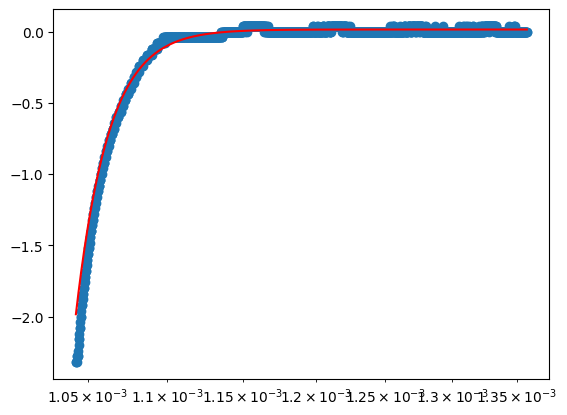

<Figure size 640x480 with 0 Axes>

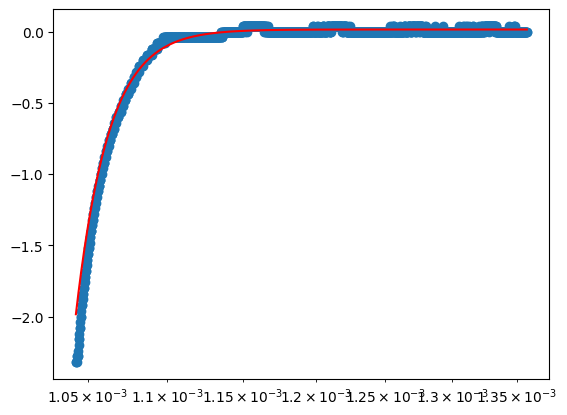

<Figure size 640x480 with 0 Axes>

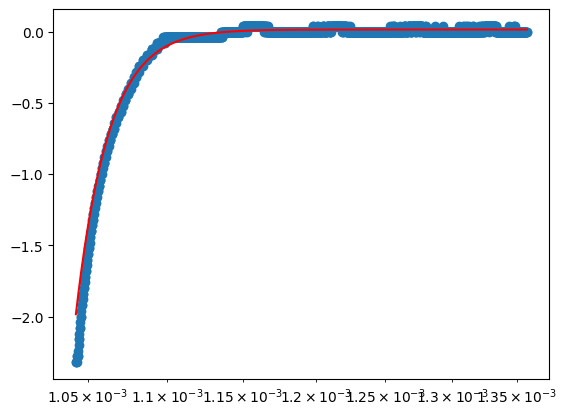

<Figure size 640x480 with 0 Axes>

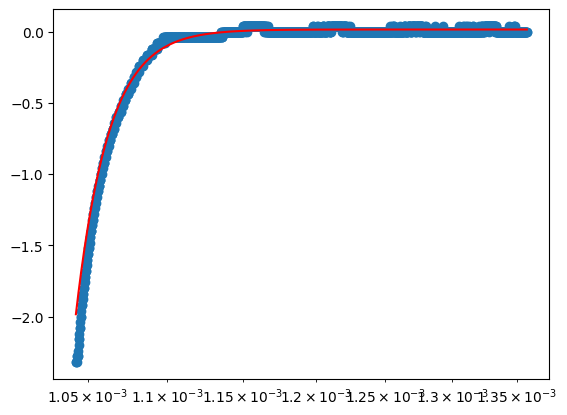

<Figure size 640x480 with 0 Axes>

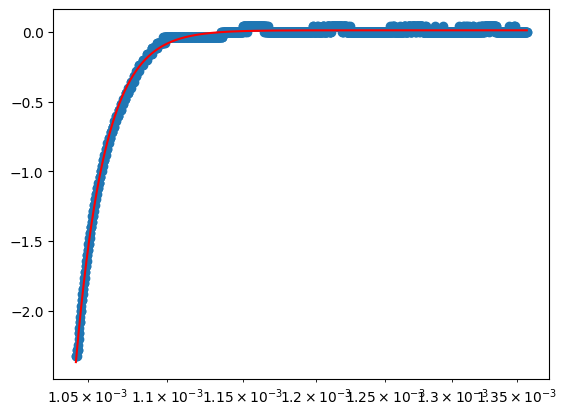

<Figure size 640x480 with 0 Axes>

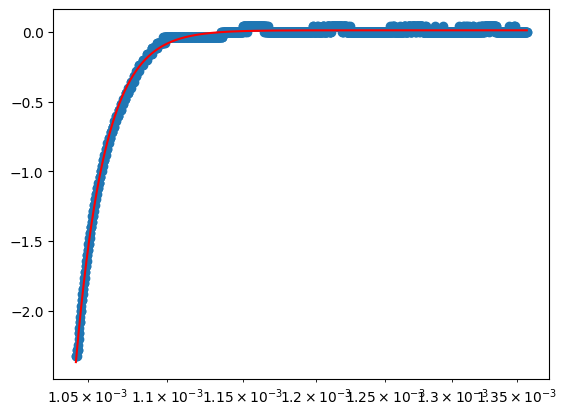

<Figure size 640x480 with 0 Axes>

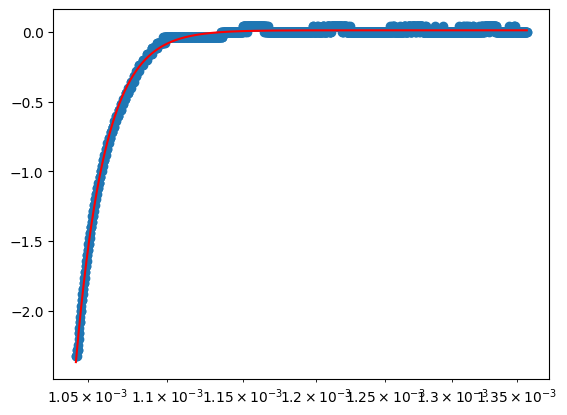

<Figure size 640x480 with 0 Axes>

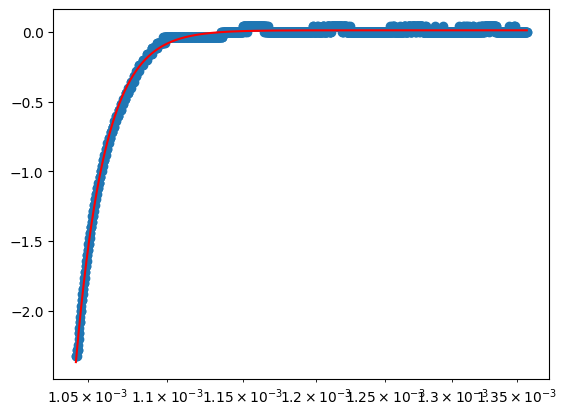

<Figure size 640x480 with 0 Axes>

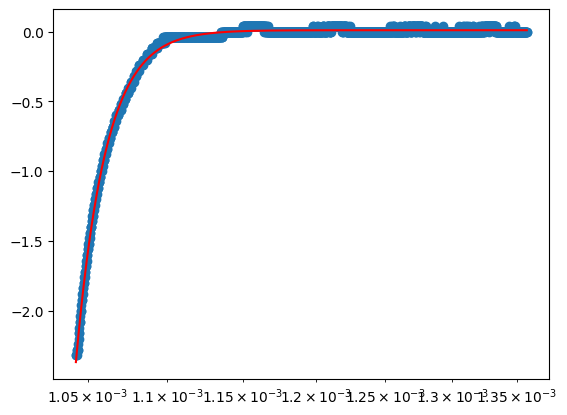

<Figure size 640x480 with 0 Axes>

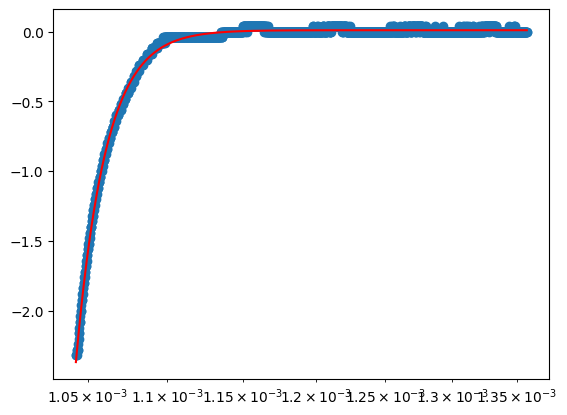

<Figure size 640x480 with 0 Axes>

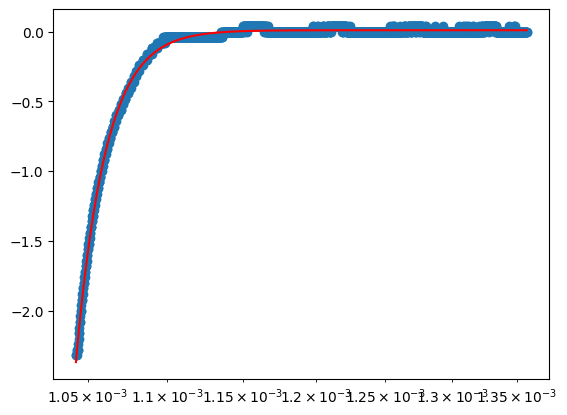

<Figure size 640x480 with 0 Axes>

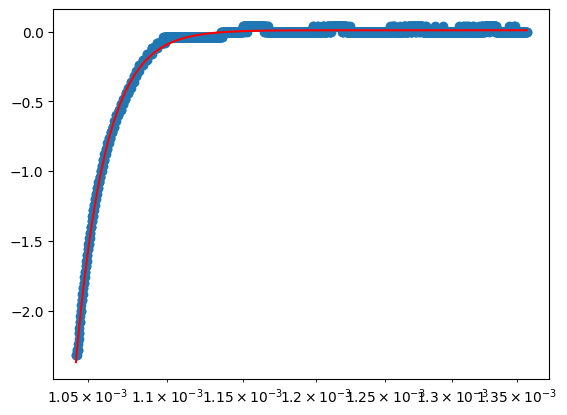

<Figure size 640x480 with 0 Axes>

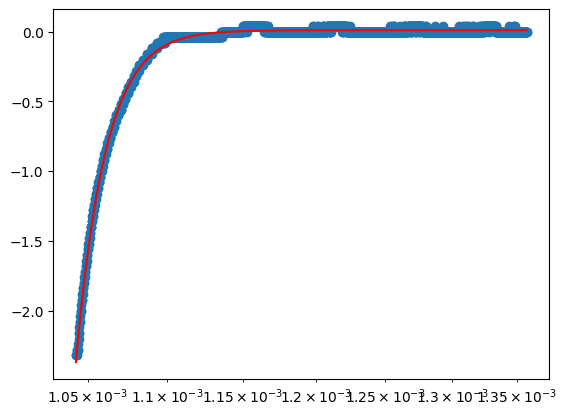

<Figure size 640x480 with 0 Axes>

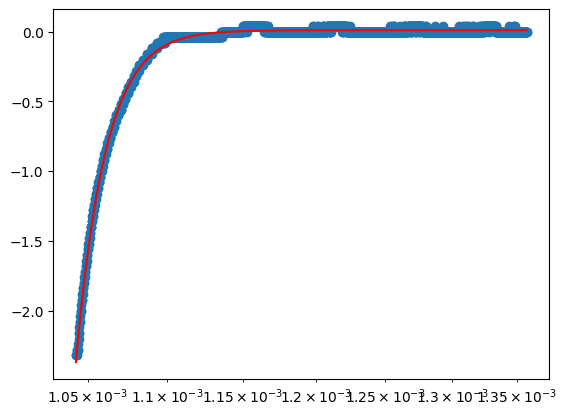

<Figure size 640x480 with 0 Axes>

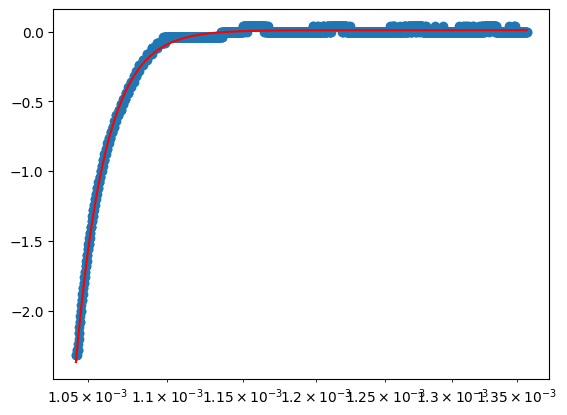

<Figure size 640x480 with 0 Axes>

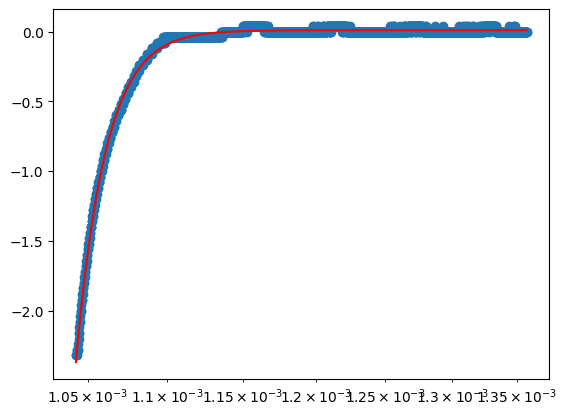

<Figure size 640x480 with 0 Axes>

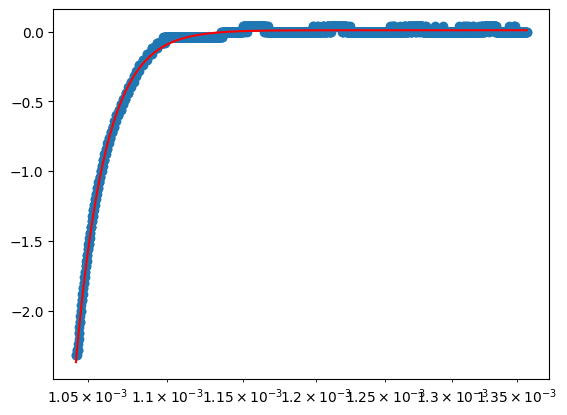

<Figure size 640x480 with 0 Axes>

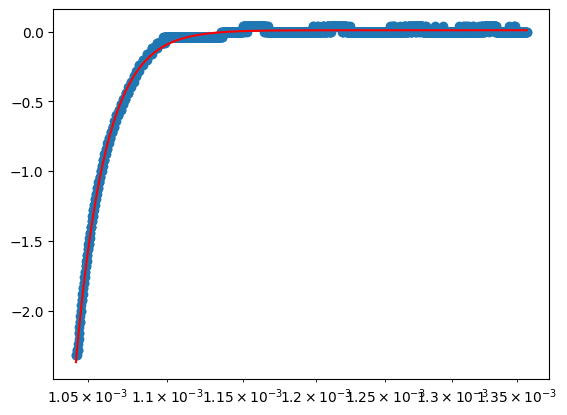

<Figure size 640x480 with 0 Axes>

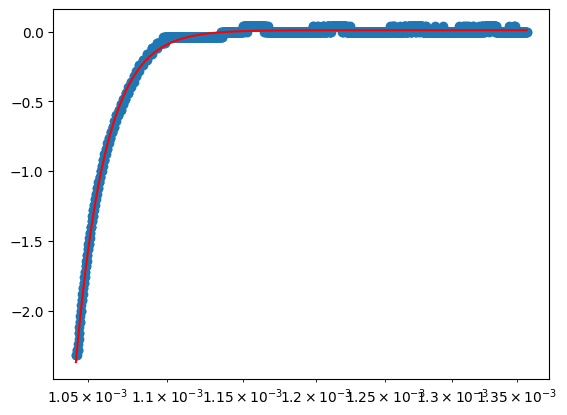

<Figure size 640x480 with 0 Axes>

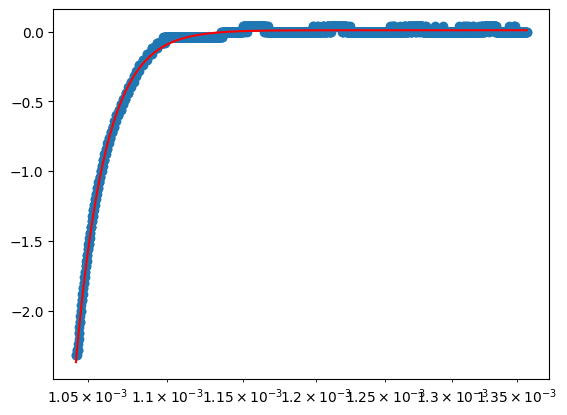

`ftol` termination condition is satisfied.
Function evaluations 5, initial cost 2.5360e+00, final cost 3.3511e-01, first-order optimality 2.39e-01.


In [22]:
res = least_squares(residuos, p_i, method ='trf', gtol=1e-8, args=(x_dato1, y_dato1), verbose=1)

In [23]:
# Estos son los parámetros hallados:
print('parámetros hallados')
print(res.x)

parámetros hallados
[-2.37871581e+00  1.81739572e-05  1.05484431e-02]


Calculamos la matriz de covarianza

In [24]:
# Calculamos la matriz de covarianza "pcov"
def calcular_cov(res,y_dato):
    U, S, V = np.linalg.svd(res.jac, full_matrices=False)
    threshold = np.finfo(float).eps * max(res.jac.shape) * S[0]
    S = S[S > threshold]
    V = V[:S.size]
    pcov = np.dot(V.T / S**2, V)

   # s_sq = 2 * res.cost / (y_dato.size - res.x.size)
    s_sq = 2 * res.cost / (len(y_dato) - len(res.x))

    pcov = pcov * s_sq
    return pcov

pcov = calcular_cov(res,y_dato)

print('Covarianza(0,1)=',pcov[0,1])


Covarianza(0,1)= 8.812663048926542e-11


De la matriz de covarinza podemos obtener los valores de desviación estándar de los parametros hallados

In [25]:
# De la matriz de covarinza podemos obtener los valores de desviación estándar
# de los parametros hallados
pstd = np.sqrt(np.diag(pcov))

print('Parámetros hallados (con incertezas):')
for i,param in enumerate(res.x):
    print('parametro[{:d}]: {:5.3e} ± {:5.3e}'.format(i,param,pstd[i]))

Parámetros hallados (con incertezas):
parametro[0]: -2.379e+00 ± 3.399e-03
parametro[1]: 1.817e-05 ± 3.961e-08
parametro[2]: 1.055e-02 ± 4.705e-04


Calculamos la suma de los cuadrados de los residuos y la suma total de cuadrados, para luego poder calcular el coeficiente de determinación $R^2$ y el Coeficiente de determinacion $R^2$ pesado por el número de parametros $R_{adj}^2$

In [26]:

# Suma de los cuadrados de los residuos
y_modelo=modelo(res.x,x_dato)

ss_res = np.sum( (y_dato - y_modelo)**2  )

# Suma total de cuadrados
ss_tot = np.sum( (y_dato - np.mean(y_dato) )**2  )

R2     = 1 - (ss_res / ss_tot)

print('Suma de los residuos = {:10.8f}'.format(ss_res))

print('Coeficiente de determinacion R2')

print('R2 = {:10.8f}'.format(R2) )

R2_adj    = 1-(1-R2) * (len(y_dato)-1)/(len(y_dato)-npar-1)

print('Coeficiente de determinacion R2 pesado por numero de parametros')

print('R2_adj = {:10.8f}'.format(R2_adj) )

Suma de los residuos = 595.08299465
Coeficiente de determinacion R2
R2 = -0.96269703
Coeficiente de determinacion R2 pesado por numero de parametros
R2_adj = -0.96505604


Calculamos el intervalo de confianza del 95% de los parámetros.

In [27]:
# Para un intervalo de 95% de confianza, necesitamos un alpha de 5% == 0.05
alpha=0.05

sT = t.ppf(1.0 - alpha/2.0, nd - npar ) # student T multiplier
CI = sT * pstd



print('')
print('Intervalo de confianza al '+str((1-alpha)*100)+'%:')
for i,param in enumerate(res.x):
    print('parametro[{:d}]: {:5.3e} ± {:5.3e}'.format(i , param , CI[i]))


Intervalo de confianza al 95.0%:
parametro[0]: -2.379e+00 ± 6.665e-03
parametro[1]: 1.817e-05 ± 7.767e-08
parametro[2]: 1.055e-02 ± 9.227e-04


Generamos la función de ajuste con los parámetros óptimos y la evaluamos en 200 valores de x.

<Figure size 640x480 with 0 Axes>

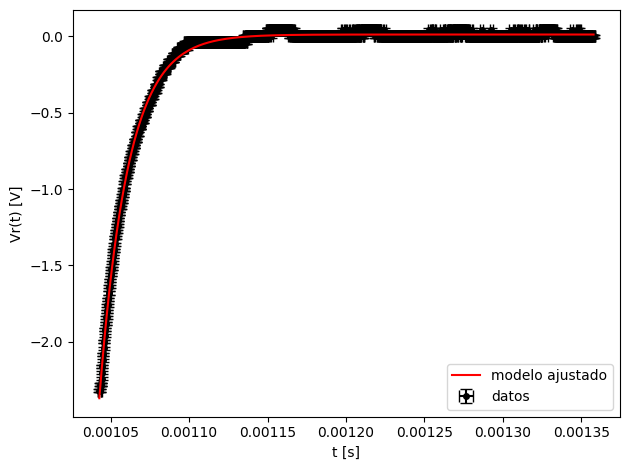

In [33]:
x_modelo  = np.linspace(x_dato1[0], x_dato1[1575], 200)
y_modelo = modelo(res.x, x_modelo)

plt.figure()
fig, (ax1) = plt.subplots(1, 1)
#ax1.set_xscale('log')
plt.errorbar(x_dato1, y_dato1, yerr=y_error1, xerr=x_error1,
             fmt='ok', capsize=4, elinewidth=1.5, ecolor='black', zorder=0, markersize=4, label='datos')

plt.plot(x_modelo, y_modelo, 'r-',               label='modelo ajustado')
plt.xlabel("t [s]")
plt.ylabel("Vr(t) [V]")
plt.legend(loc='best')
#plt.text(-5, -10, r'$R^2$ = {:10.8f}'.format(R2_adj))
# plt.text(-5, -11.5, r'p[0] = {:5.3e}'.format(res.x[0]))
plt.tight_layout()


Hacemos un gráfico de los residuos del ajuste

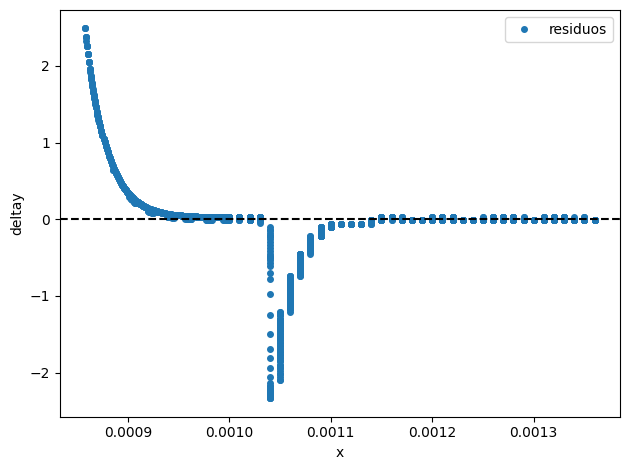

In [ ]:
y_modelo = modelo(res.x, x_dato)

plt.figure()
plt.plot(x_dato, y_dato-y_modelo ,  'o', markersize=4, label='residuos')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("x")
plt.ylabel("deltay")
plt.legend(loc='best')
plt.tight_layout()

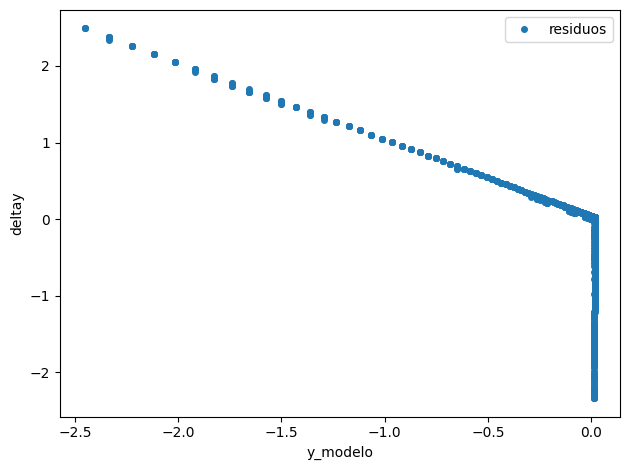

In [ ]:
y_modelo = modelo(res.x, x_dato)

plt.figure()
plt.plot(y_modelo, y_dato-y_modelo ,  'o', markersize=4, label='residuos')
plt.xlabel("y_modelo")
plt.ylabel("deltay")
plt.legend(loc='best')
plt.tight_layout()

Generamos el histograma de los residuos. El argumento "bins", en la función "hist" determina el intervalo de partición. Por ejemplo "bins=10" divide el rango total en 10 intervalos. Ud. debe modificarlo de acuerdo a la cantidad de datos experimentales adquiridos.

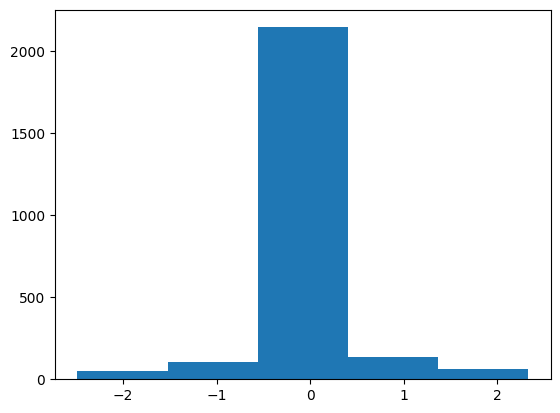

In [ ]:
# create histogram
plt.figure()
plt.hist(y_modelo-y_dato, bins=5, density=False)

# display histogram
plt.show()

Aqui calculamos los valores de la media  μ  y de la desviación standard  σ  de los residuos. Con estos calculamos la curva teórica de la distribucón normal en el rango observado

In [ ]:
# Valores de la media (mu) y desviación típica (sigma) de los datos
mu, sigma = stats.norm.fit(y_modelo-y_dato)

# Valores teóricos de la normal en el rango observado
x_hat = np.linspace(min(y_modelo-y_dato), max(y_modelo-y_dato), num=100)
y_hat = stats.norm.pdf(x_hat, mu, sigma)


In [ ]:
print("μ = {:6.4f}".format(mu), "σ = {:6.4f}" .format(sigma))

μ = -0.0030 σ = 0.5111


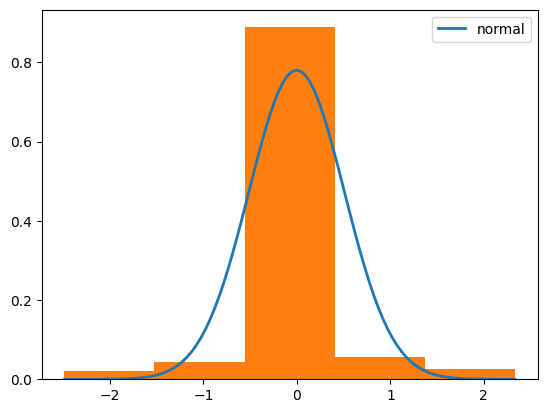

In [ ]:
plt.figure()
plt.plot(x_hat, y_hat, linewidth=2, label='normal')
plt.legend(loc='best')
plt.hist(y_modelo-y_dato, bins=5, density=True)
plt.show()